<a href="https://colab.research.google.com/github/NehaSusan14/6THSEM-ML-LAB/blob/main/1BM23CS210_LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving iris (1).csv to iris (1).csv
Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



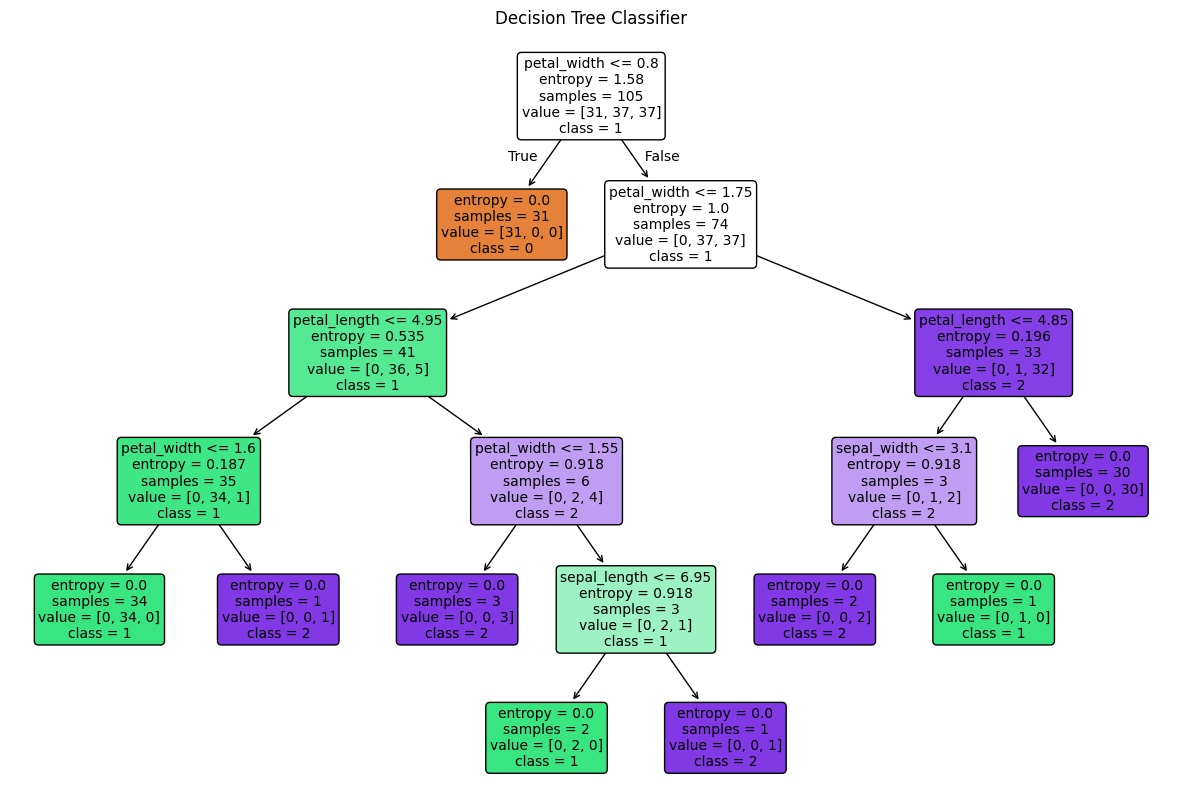

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Create the dataset by uploading a CSV file
from google.colab import files
data = files.upload()

# Assuming the uploaded file is a single CSV, get its name
file_name = next(iter(data))
df = pd.read_csv(file_name)

# Convert categorical data to numerical data using LabelEncoder
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object': # Check for object type (usually strings/categorical)
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

# Assuming the last column is the target column for classification, named 'Classification'
# You might need to adjust 'Classification' to your actual target column name
if 'Classification' in df.columns:
    X = df.drop('Classification', axis=1)
    y = df['Classification']
else:
    print("Warning: 'Classification' column not found. Please ensure your target column is correctly named.")
    # Fallback: assume the last column is the target if 'Classification' is not found
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier with entropy as the criterion
clf = DecisionTreeClassifier(criterion='entropy')

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# For classification report, try to get class names if available, or use numerical labels
if 'Classification' in label_encoders:
    target_names = label_encoders['Classification'].classes_.astype(str)
else:
    target_names = [str(c) for c in sorted(y.unique())]
print(classification_report(y_test, y_pred, target_names=target_names))

# Optionally, visualize the decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10)) # Adjust figure size for better readability
plot_tree(clf, filled=True, feature_names=X.columns, class_names=target_names, rounded=True, fontsize=10)
plt.title("Decision Tree Classifier")
plt.show()

Please upload your 'drugdataset.csv' file.


Saving drug.csv to drug (1).csv
Original DataFrame head:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


DataFrame head after encoding:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4



Accuracy for Drug Dataset: 1.00

Classification Report for Drug Dataset:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         6
       drugX       1.00      1.00      1.00        18
       drugY       1.00      1.00      1.00        26

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



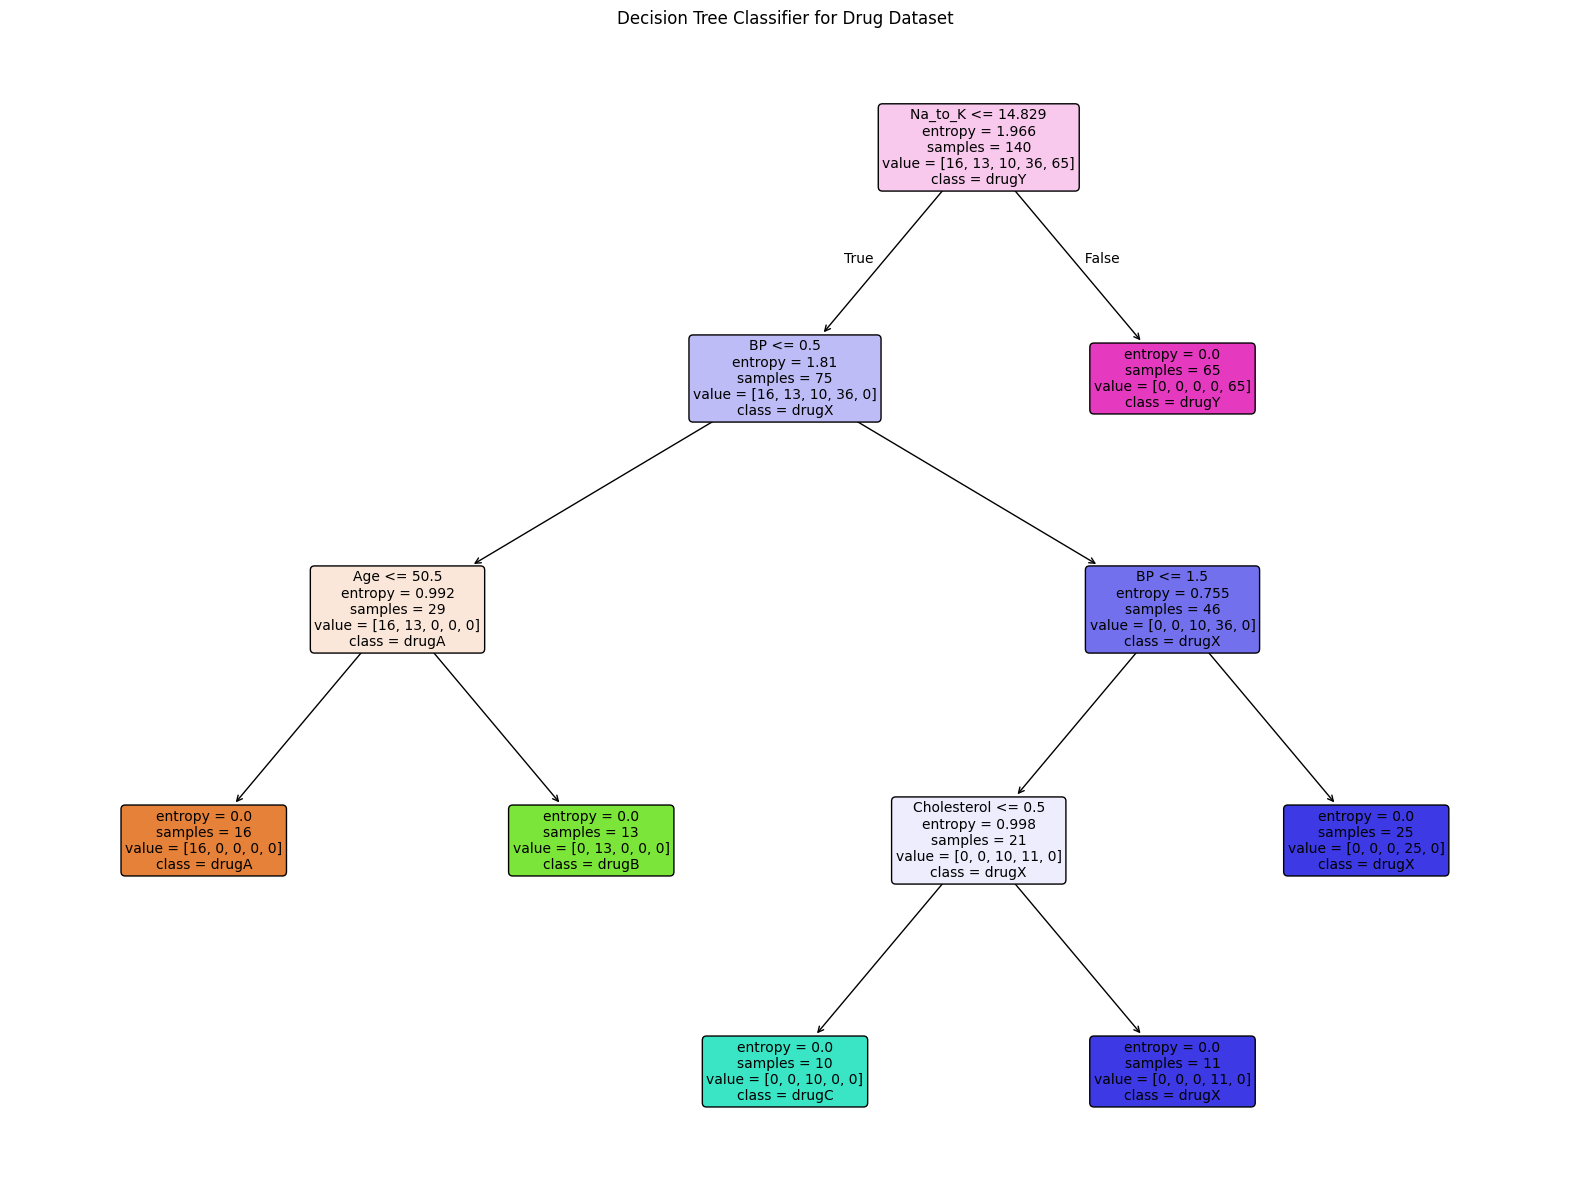

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("Please upload your 'drugdataset.csv' file.")
data = files.upload()

# Assuming the uploaded file is a single CSV, get its name
file_name = next(iter(data))
df_drug = pd.read_csv(file_name)

# Display the first few rows of the dataset
print("Original DataFrame head:")
display(df_drug.head())

# Convert categorical data to numerical data using LabelEncoder
label_encoders_drug = {}
# Corrected column names to match the uploaded CSV
for column in ['Sex', 'BP', 'Cholesterol', 'Drug']:
    if column in df_drug.columns and df_drug[column].dtype == 'object':
        le = LabelEncoder()
        df_drug[column] = le.fit_transform(df_drug[column])
        label_encoders_drug[column] = le
    elif column not in df_drug.columns:
        print(f"Warning: Column '{column}' not found in the dataset.")


# Define features (X) and target (y) for the drug dataset
# Corrected column names to match the uploaded CSV
features = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
# Filter out any features that were not found in the dataframe
features_found = [f for f in features if f in df_drug.columns]
X_drug = df_drug[features_found]

# Ensure 'Drug' column exists before trying to access it
if 'Drug' in df_drug.columns:
    y_drug = df_drug['Drug']
else:
    raise ValueError("Target column 'Drug' not found in the dataset.")


print("DataFrame head after encoding:")
display(df_drug.head())

# Split the data into training and testing sets
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug, y_drug, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier with entropy as the criterion
clf_drug = DecisionTreeClassifier(criterion='entropy')

# Train the classifier
clf_drug.fit(X_train_drug, y_train_drug)

# Make predictions
y_pred_drug = clf_drug.predict(X_test_drug)

# Evaluate the classifier
accuracy_drug = accuracy_score(y_test_drug, y_pred_drug)
print(f'\nAccuracy for Drug Dataset: {accuracy_drug:.2f}')

# Get target names for the classification report
if 'Drug' in label_encoders_drug:
    target_names_drug = label_encoders_drug['Drug'].classes_.astype(str)
else:
    target_names_drug = [str(c) for c in sorted(y_drug.unique())]

print('\nClassification Report for Drug Dataset:')
print(classification_report(y_test_drug, y_pred_drug, target_names=target_names_drug))

# Visualize the decision tree
plt.figure(figsize=(20,15)) # Adjust figure size for better readability
plot_tree(clf_drug, filled=True, feature_names=X_drug.columns, class_names=target_names_drug, rounded=True, fontsize=10)
plt.title("Decision Tree Classifier for Drug Dataset")
plt.show()

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
import numpy as np
from google.colab import files # Import files for upload

# 1. Load the dataset
print("Please upload your 'petrol_consumption.csv' file.")
data = files.upload() # Prompt user to upload the file

# Assuming the uploaded file is a single CSV, get its name
file_name = next(iter(data))
dataset = pd.read_csv(file_name)

# The features are all columns except 'Petrol_Consumption', which is the target variable
X = dataset.drop('Petrol_Consumption', axis=1)
y = dataset['Petrol_Consumption']

# 2. Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. Build the Regression Tree model
# Instantiate the DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=0)

# Fit the model to the training data
regressor.fit(X_train, y_train)

# 4. Predict petrol consumption on the test data
y_pred = regressor.predict(X_test)

# 5. Display the evaluation metrics
print("Evaluation Metrics for Test Data:")
print("Mean Absolute Error (MAE):", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Please upload your 'petrol_consumption.csv' file.


Saving petrol_consumption.csv to petrol_consumption.csv
Evaluation Metrics for Test Data:
Mean Absolute Error (MAE): 50.8
Mean Squared Error (MSE): 4535.4
Root Mean Squared Error (RMSE): 67.34537846058926
